In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from simplicial_complex import SimplicialComplex

### Rips complex in 2D

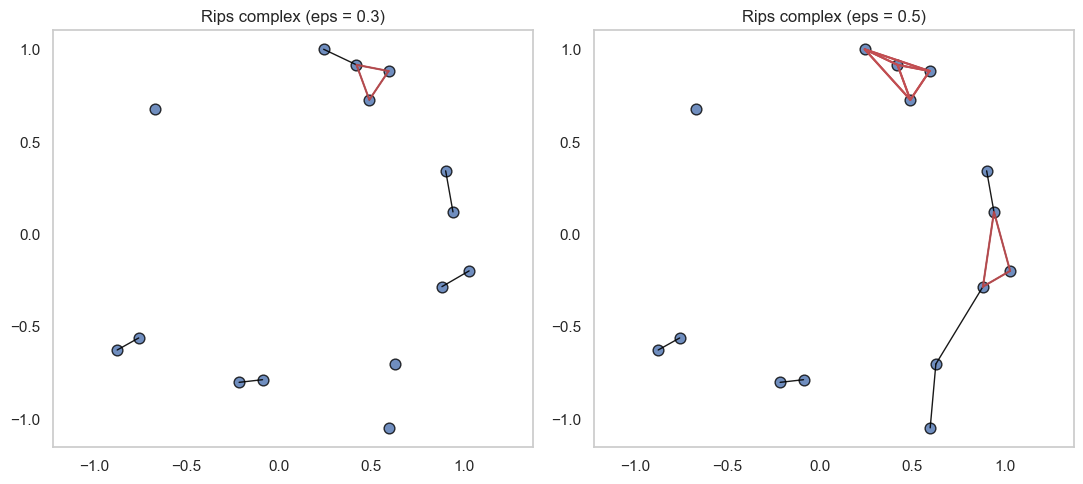

In [24]:
np.random.seed(42)

n_samples = 15
radius = 1.0
noise_level = 0.08

angles = np.random.uniform(0, 2 * np.pi, n_samples)
noise = np.random.normal(0, noise_level, n_samples)
noisy_radius = radius + noise

x = noisy_radius * np.cos(angles)
y = noisy_radius * np.sin(angles)

dataset = np.column_stack((x, y))


fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, eps in zip(axes, [0.3, 0.5]):

    complex = SimplicialComplex()
    rips = complex.rips_complex(dataset, eps)

    edges = rips.by_dim.get(1, [])
    triangles = rips.by_dim.get(2, [])

    ax.scatter(dataset[:, 0], dataset[:, 1],
               color=sns.color_palette()[0],
               s=60, edgecolor='black', alpha=0.8)

    ax.set_title(f"Rips complex (eps = {eps})")
    ax.axis('equal')
    ax.grid(False)

    for s in edges:
        i, j = s.vertices
        ax.plot([dataset[i, 0], dataset[j, 0]],
                [dataset[i, 1], dataset[j, 1]],
                color="black", alpha=0.9, linewidth=1)

    for s in triangles:
        i, j, k = s.vertices
        poly = dataset[[i, j, k, i]]
        ax.plot(poly[:, 0], poly[:, 1],
                color=sns.color_palette()[3], alpha=0.9)

plt.tight_layout()
plt.show()